## Objective:
To predict the future state of a chaotic deterministic system (Double Pendulum) under conditions of strict partial observability. An LSTM network is deployed to infer hidden physical constraints (Mass 1 kinematics) strictly from incomplete sequential data (Mass 2 trajectory).

### Kinematics of the double pendulum
#### Positions
$$x_1 = L_1 \sin \theta_1$$
$$y_1 = -L_1 \cos \theta_1$$
$$x_2 = x_1 + L_2 \sin \theta_2$$
$$y_2 = y_1 - L_2 \cos \theta_2$$

#### Velocities
$$\dot{x}_1 = \dot{\theta_1} L_1 \cos \theta_1$$
$$\dot{y_1} =  \dot{\theta_1} L_1 \sin \theta_1$$
$$\dot{x_2} = \dot{x_1} + \dot{\theta_2} L_2 \cos \theta_2$$
$$\dot{y_2} = \dot{y_1} + \dot{\theta_2} L_2 \sin \theta_2$$


#### Accelerations

$$\ddot{x}_1 = -\dot{\theta_1}^2 L_1 \sin \theta_1 + \ddot{\theta_1} L_1 \cos \theta_1$$
$$\ddot{y_1} =  \dot{\theta_1}^2 L_1 \cos \theta_1 + \ddot{\theta_1} L_1 \sin \theta_1$$
$$\ddot{x_2} = \ddot{x_1} - \dot{\theta_2}^2 L_2 \sin \theta_2 + \ddot{\theta_2} L_2 \cos \theta_2$$
$$\ddot{y_2} = \ddot{y_1} + \dot{\theta_2}^2 L_2 \cos \theta_2 + \ddot{\theta_2} L_2 \sin \theta_2$$

#### Energies
Let $v_1^2 = \dot{x_1}^2 +\dot{y_1}^2$ and $v_2^2 = \dot{x_2}^2 +\dot{y_2}^2$ then the kinetic energies $T_1$ and $T_2$ are
$$ T_1 = \frac{1}{2}m_1 v_1^2 = \frac{1}{2}m_1 L_1^2 \dot{\theta_1}^2 $$
$$ T_2 = \frac{1}{2}m_2 v_2^2 = \frac{1}{2}m_2 \left( L_1^2 \dot{\theta_1}^2 + L_2^2 \dot{\theta_2}^2 + 2L_1 L_2 \cos(\theta_1-\theta_2) \dot{\theta_1} \dot{\theta_2} \right) $$

The potential energies are
$$V_1 = m_1 g y_1 = - m_1 g L_1 \cos \theta_1$$
$$V_2 = m_2 g y_2 = -m_2 g ( L_1 \cos \theta_1 + L_2 \cos \theta_2)$$

#### Langrangian
Now we form the Lagrangian $L=T-V=T_1+T_2 -V_1 -V_2$ and use the Euler-Lagrange equations:
$$\frac{\partial L}{\partial \theta_1} = \frac{d}{dt}\frac{\partial L}{\partial \dot{\theta_1}}$$
$$\frac{\partial L}{\partial \theta_2} = \frac{d}{dt}\frac{\partial L}{\partial \dot{\theta_2}}$$

Applying these gives
$$-(m_1+m_2) g L_1 \sin \theta_1 = (m_1+m_2) L_1^2 \ddot{\theta_1} + m_2 L_1 L_2 \sin(\theta_1-\theta_2) \dot{\theta_2}^2 +  m_2 L_1 L_2 \cos(\theta_1-\theta_2) \ddot{\theta_2} $$
and
$$ -m_2 g L_2 \sin \theta_2 = m_2 L_2 \ddot{\theta_2} + m_2 L_1 L_2 \cos(\theta_1-\theta_2) \ddot{\theta_1} + m_2 L_1 L_2 \sin(\theta_1-\theta_2) \dot{\theta_1}^2 $$ 


#### Equations of motions
$$ \omega_1 = \dot{\theta_1} $$  

$$ \omega_2 = \dot{\theta_2} $$ 
$$ \ddot\theta_1 = \frac{1}{L_1\xi}\left[L_1m_2\cos(\theta_1-\theta_2)\sin(\theta_1-\theta_2)\omega_1^2 + L_2m_2\sin(\theta_1-\theta_2)\omega_2^2 - m_2g\cos(\theta_1-\theta_2)\sin(\theta_2) + (m_1+m_2)g\sin(\theta_1) \right] $$
$$ \ddot\theta_2 = \frac{1}{L_2\xi}\left[L_2m_2\cos(\theta_1-\theta_2)\sin(\theta_1-\theta_2)\omega_2^2 + L_1(m_1+m_2)\sin(\theta_1-\theta_2)\omega_1^2+(m_1+m_2)g\sin(\theta_1)\cos(\theta_1-\theta_2) - (m_1+m_2)g\sin(\theta_2) \right] $$
where 
$$\xi \equiv \cos^2(\theta_1-\theta_2)m_2-m_1-m_2$$


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

# Add the project root to the path so Jupyter can see the 'src' folder
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Import your custom modularized backend
from src.pendulum_env import DoublePendulum
from src.lstm_pipeline import create_windows_vectorized, build_lstm_model

# Set default figure settings
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi'] = 200

In [3]:
# instantiate the environment
env = DoublePendulum()

# generate data using the class
pendulum_data, times = env.generate_data([np.pi/4, 0, np.pi/4, 0], 2000)

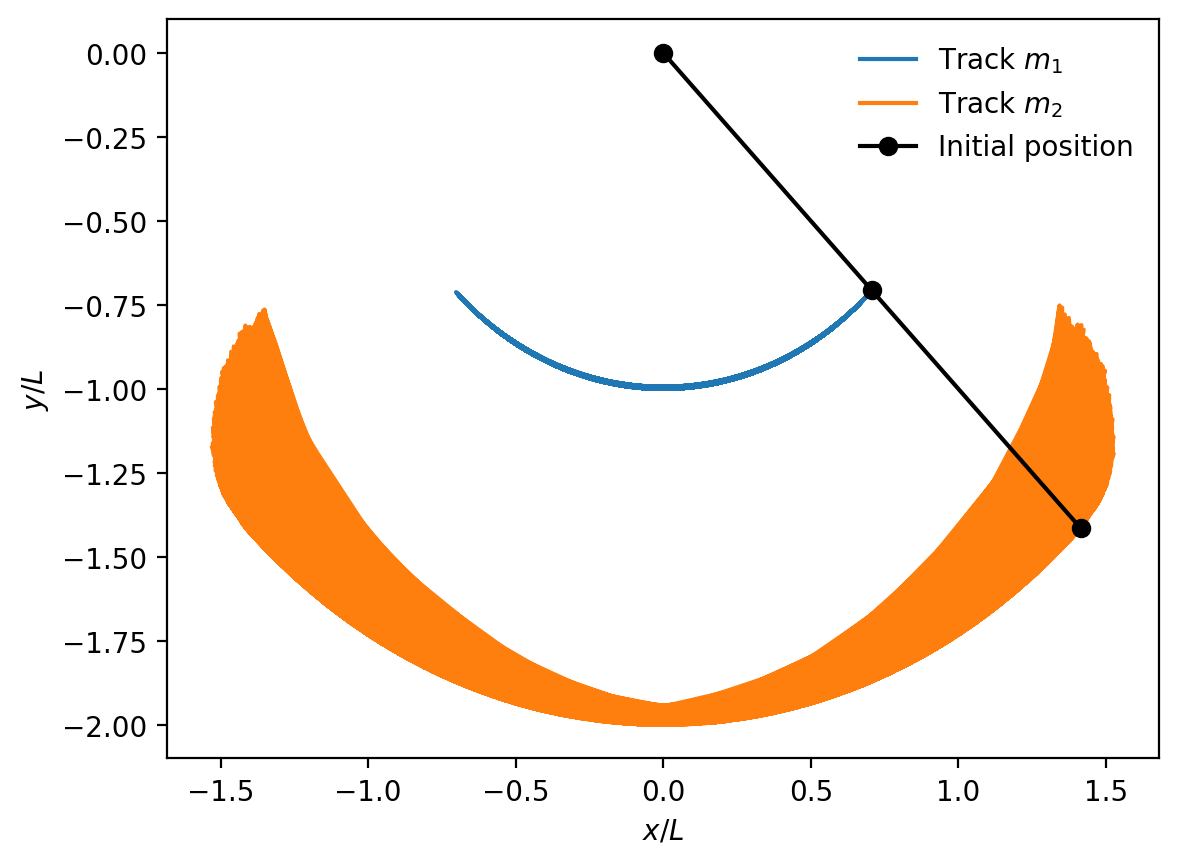

In [4]:
x1 = pendulum_data[:, 0]
y1 = pendulum_data[:, 1]
x2 = pendulum_data[:, 2]
y2 = pendulum_data[:, 3]

fig,ax=plt.subplots()
ax.plot(x1, y1, label=r"Track $m_1$")
ax.plot(x2, y2, label=r"Track $m_2$")
ax.plot([0, x1[0], x2[0]], [0, y1[0], y2[0]], "-o", label="Initial position", c='k')
plt.ylabel(r"$y/L$")
plt.xlabel(r"$x/L$")
ax.legend()

## Training a recurrent neural network to predict future positions

In [5]:
# instantiate the environment
env = DoublePendulum()

# generate data using the class
pendulum_data, times = env.generate_data([np.pi/4, 0, np.pi/4, 0], 2000)

In [6]:
#builds the model
model = build_lstm_model(input_dim=4, output_dim=4)

In [7]:
#Define global parameters
windowsize = 15
offset = 20
batch_size = 128
dt = 0.1

#Instantiate the environment and generate baseline data
env = DoublePendulum(dt=dt)
pendulum_data, times = env.generate_data([np.pi/4, 0, np.pi/4, 0], 2000)

#Split chronologically to prevent look-ahead bias
train_size = int(len(pendulum_data) * 0.8)
train_data = pendulum_data[:train_size]
test_data = pendulum_data[train_size:]

#Scale the data (fit only on training data to prevent leakage)
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

#Format data into inputs and labels using your vectorized function
X_train, y_train = create_windows_vectorized(train_data_scaled, windowsize, offset)
X_test, y_test = create_windows_vectorized(test_data_scaled, windowsize, offset)

print("X_train shape:", X_train.shape) 
print("y_train shape:", y_train.shape) 
print("X_test shape:", X_test.shape) 

#Build the model using your custom pipeline function
model = build_lstm_model(input_dim=4, output_dim=4, window_size=windowsize)

X_train shape: (15966, 15, 4)
y_train shape: (15966, 4)
X_test shape: (3967, 15, 4)


In [8]:
# Initialize Early Stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# Train the network using Keras standard protocols
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    shuffle=True
)


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2401 - val_loss: 0.0439
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0205 - val_loss: 0.0074
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0071 - val_loss: 0.0050
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - val_loss: 0.0027
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - val_loss: 9.2456e-04
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012 - val_loss: 7.1581e-04
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - val_loss: 6.5678e-04
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━

C:\Users\Deadl\AppData\Local\Temp\ipykernel_4828\2435198188.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


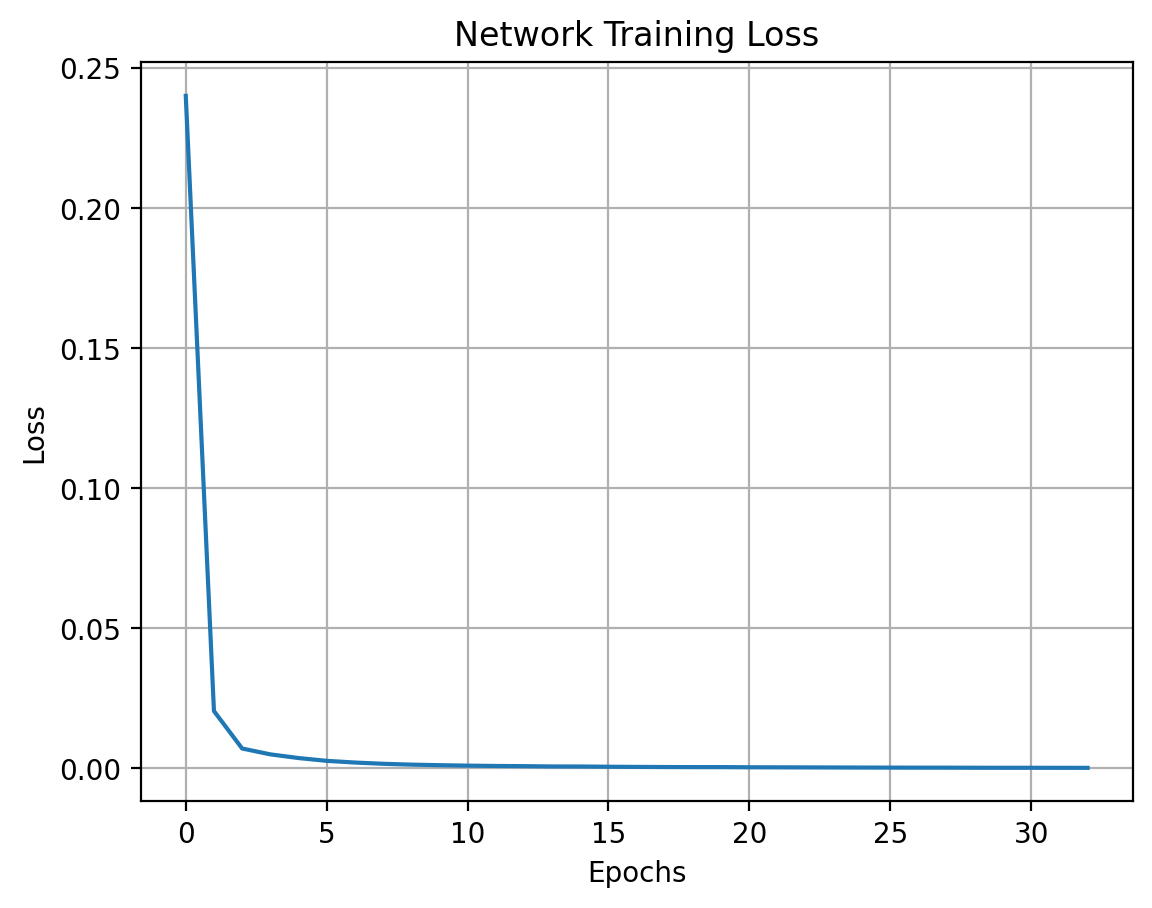

In [9]:
# Plot costs vs steps
fig, ax = plt.subplots()
ax.plot(history.history['loss'])
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.set_title("Network Training Loss")
#ax.set_yscale('log')
ax.grid()
ax.legend()
plt.show()

### Plot showing stability of network under differing initial conditions

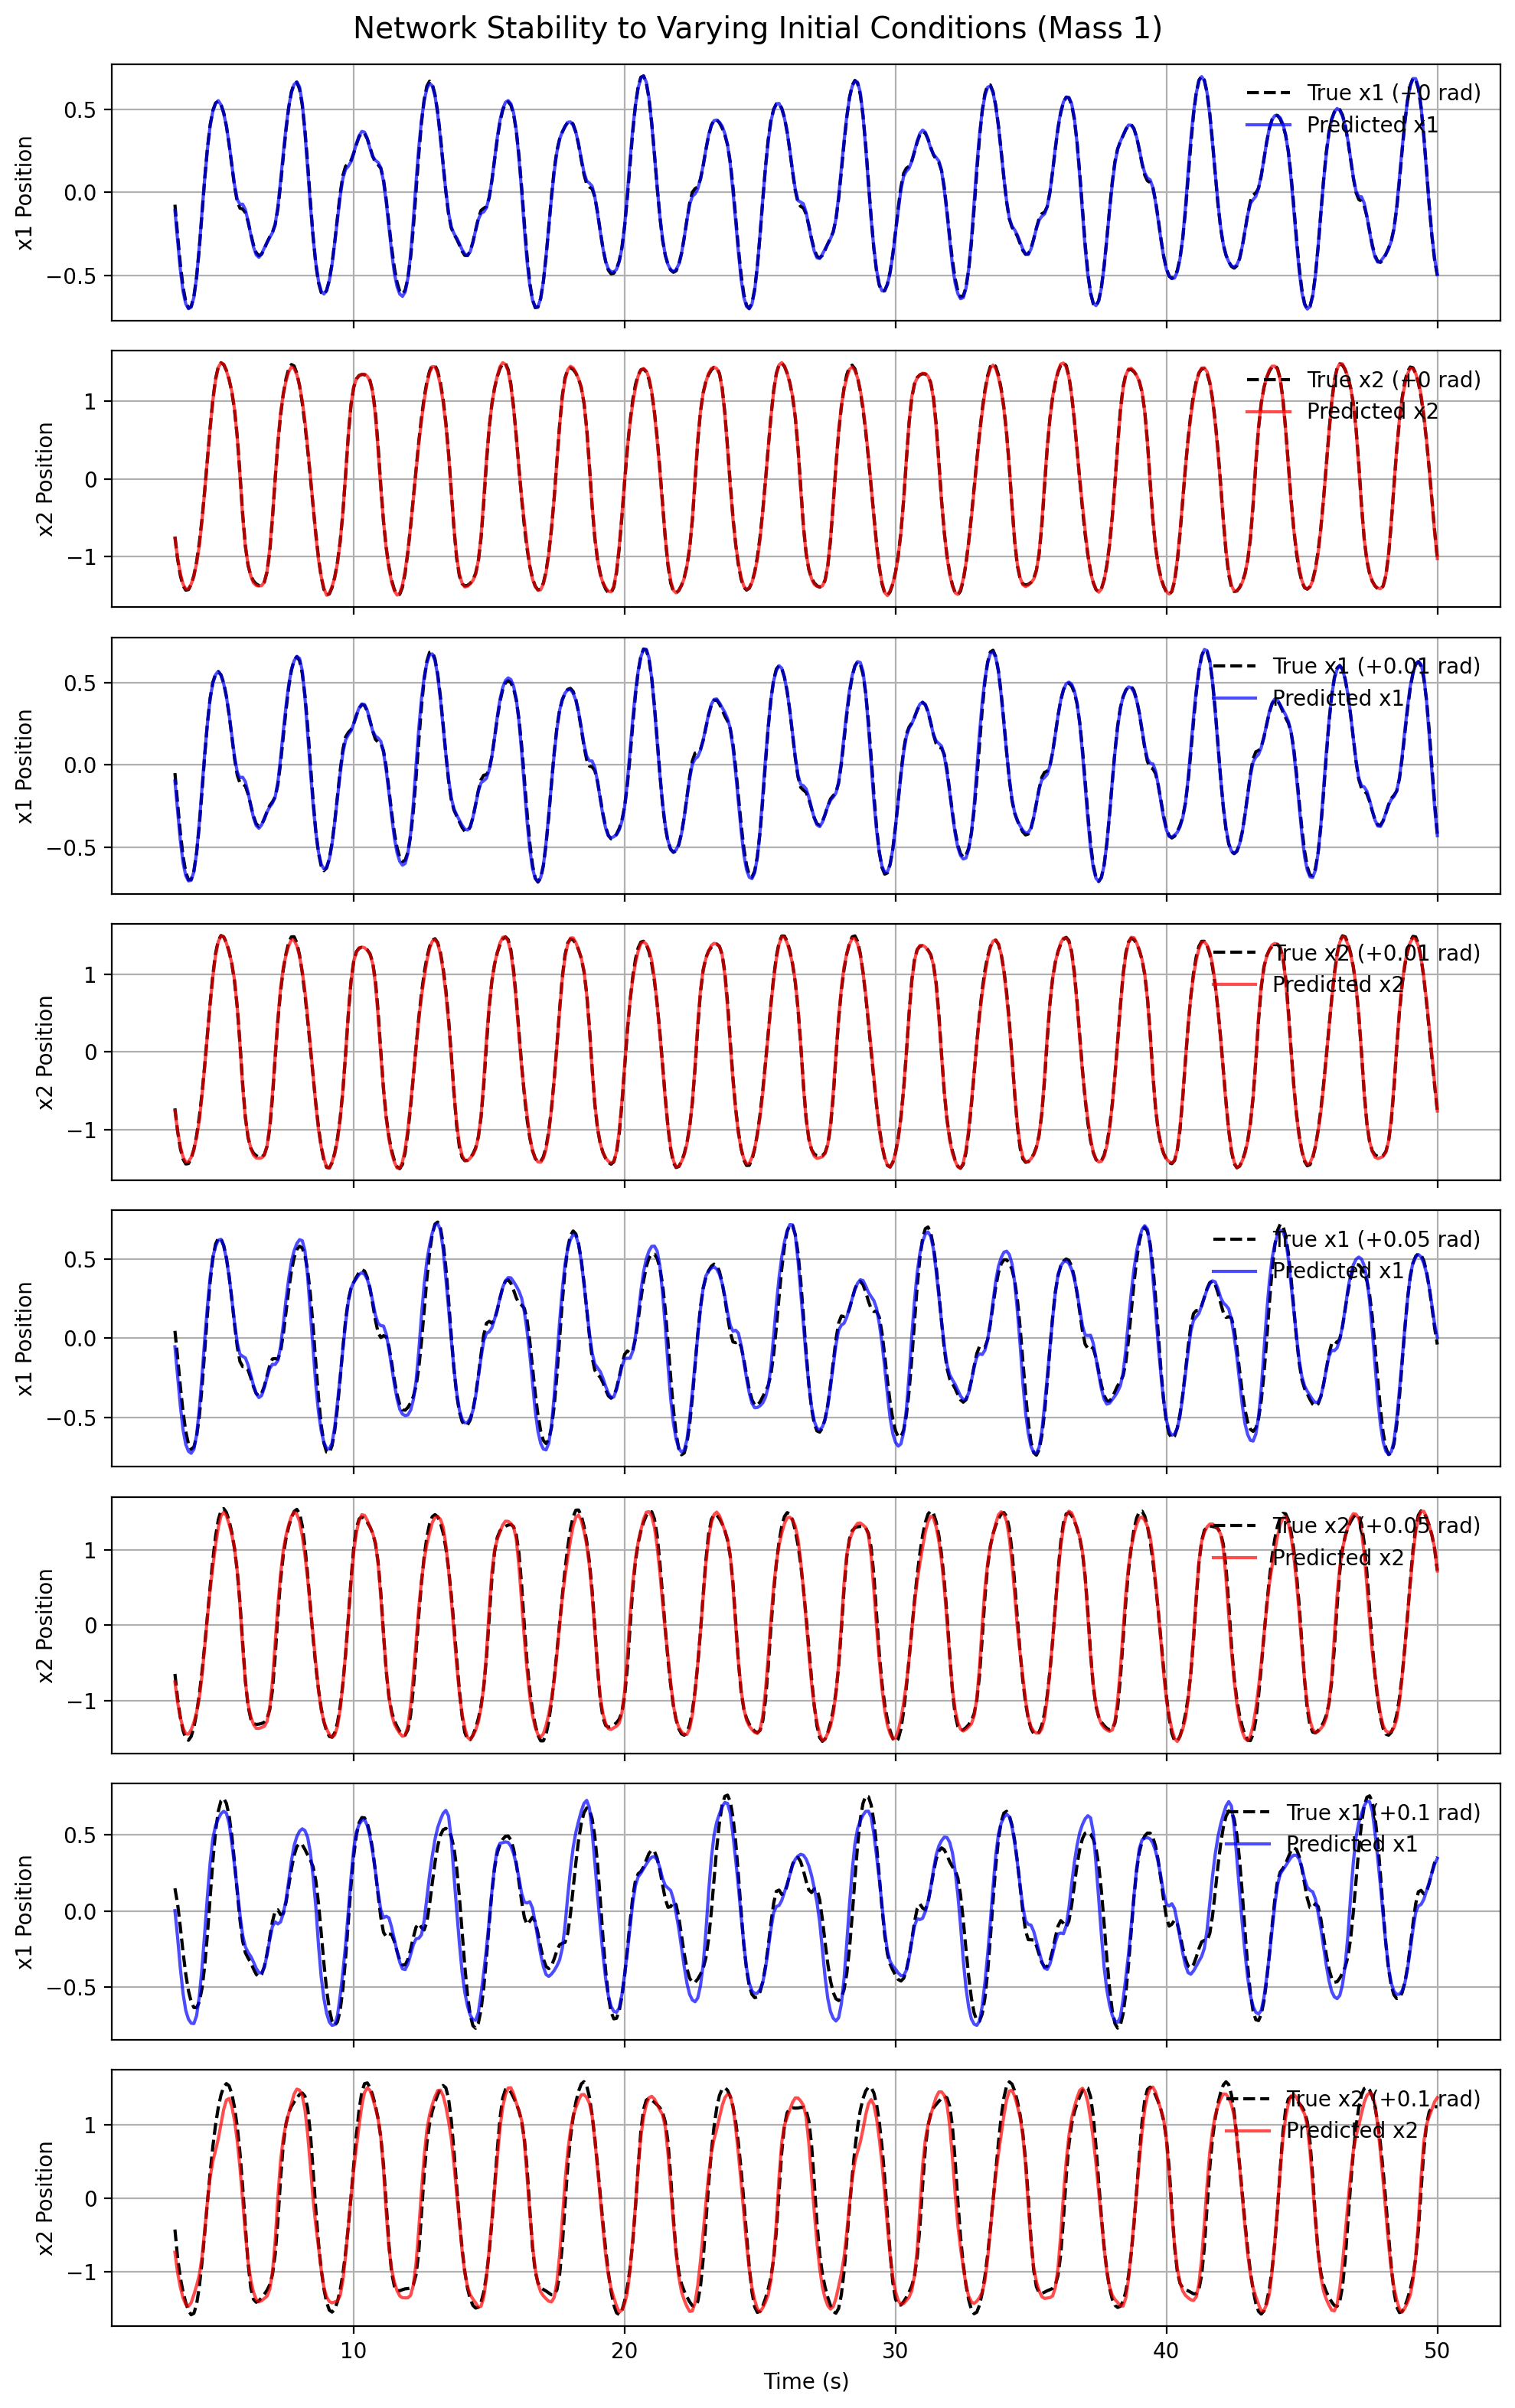

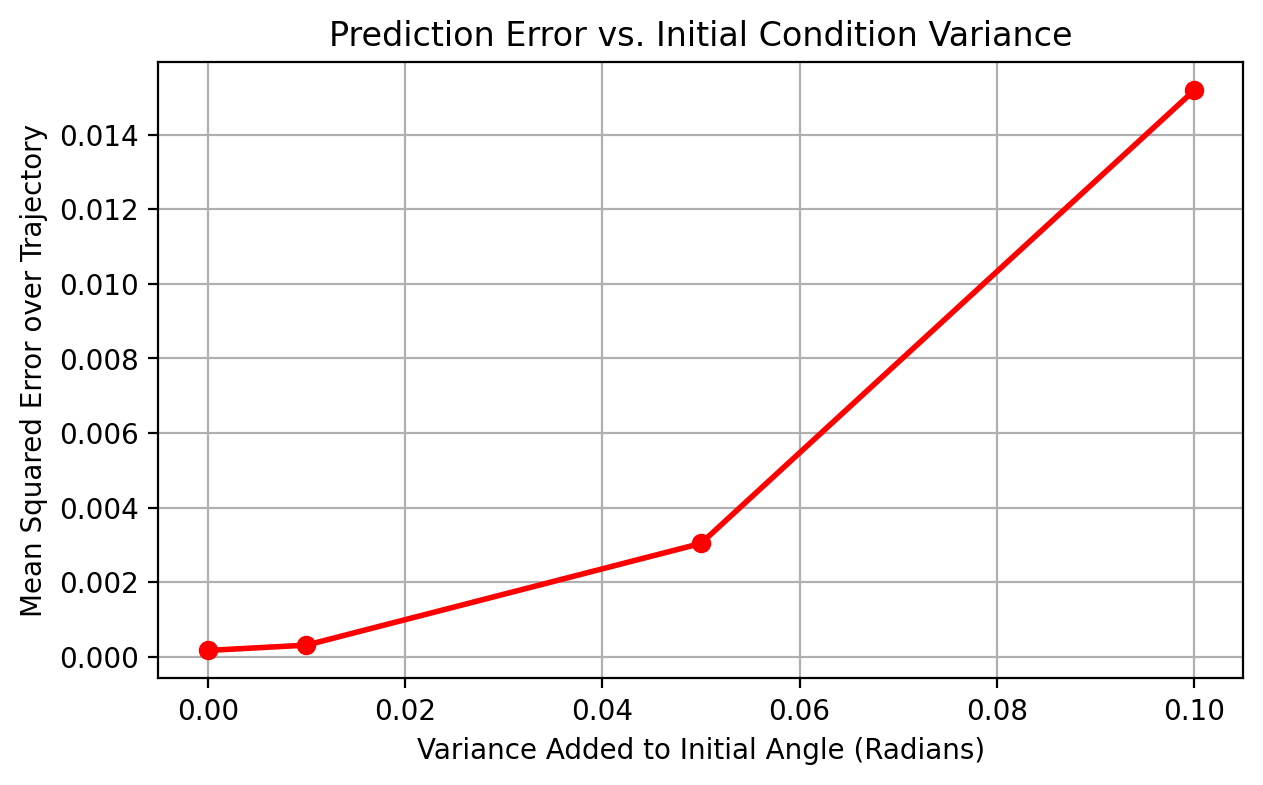

In [18]:
from sklearn.metrics import mean_squared_error

# define variations to test
variations = [0, 0.01, 0.05, 0.1]
errors = []

# create a figure
fig, axes = plt.subplots(2*len(variations), 1, figsize=(10, 16), sharex=True)
fig.suptitle("Network Stability to Varying Initial Conditions (Mass 1)", fontsize=14)

# create a time array for 50 second test run
tmax_test = 50
t_test = np.arange(0, tmax_test + dt, dt)
t_plot = t_test[windowsize + offset - 1 : ] # creates time array starting from the first xlabel

# loop over different variations
for i, var in enumerate(variations):
    
    # define a new initial condition array
    z0_var = [np.pi/4 + var, 0, np.pi/4, 0]
    
    # solve differential equations for the new conditions and format it into (501,4)
    var_data, _ = env.generate_data(z0_var, tmax_test)
    var_data_scaled = scaler.transform(var_data)

    # pass the array into the function that creates overlapping windows 
    xInput_var, xLabel_var_scaled = create_windows_vectorized(var_data_scaled, windowsize, offset)

    # model makes predictions on the test window using scaled inputs
    predictions_var_scaled = model.predict(xInput_var, verbose=0)
    
    predictions_var = scaler.inverse_transform(predictions_var_scaled)
    xLabel_var = scaler.inverse_transform(xLabel_var_scaled)
   
    #Calculate Total Error (MSE) for this trajectory in physical space
    mse = mean_squared_error(xLabel_var, predictions_var)
    errors.append(mse)
    
    # plots the truth array and the predictions array

    # mass1
    ax = axes[2*i]
    ax.plot(t_plot, xLabel_var[:, 0], label=f"True x1 (+{var} rad)", color='black', linestyle='dashed')
    ax.plot(t_plot, predictions_var[:, 0], label=f"Predicted x1", color='blue', alpha=0.7)
    ax.set_ylabel("x1 Position")
    ax.legend(loc="upper right")
    ax.grid()

    # mass2
    ax2 = axes[2*i+1]
    ax2.plot(t_plot, xLabel_var[:, 2], label=f"True x2 (+{var} rad)", color='black', linestyle='dashed')
    ax2.plot(t_plot, predictions_var[:, 2], label="Predicted x2", color='red', alpha=0.7)
    ax2.set_ylabel("x2 Position")
    ax2.legend(loc="upper right")
    ax2.grid()

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.subplots_adjust(top=0.96) # Adjust top to ensure suptitle is visible
plt.show()

# plot Error vs Variance
plt.figure(figsize=(7, 4))
plt.plot(variations, errors, marker='o', color='red', linestyle='-', linewidth=2)
plt.title("Prediction Error vs. Initial Condition Variance")
plt.xlabel("Variance Added to Initial Angle (Radians)")
plt.ylabel("Mean Squared Error over Trajectory")
plt.grid(True)
plt.show()

Based on the graphs above, we can see that there is increased deviation from the true values to the predicted values. This is more clearly shown in the final plot, where MSE increases as the variance we add increases.

## Determining how far in the future the neural network can predict

In [11]:
# define the range of offsets 
offsets_to_test = [20, 40, 60, 80, 100]
extrapolation_errors = []

# generate data
test_data, t_test = env.generate_data([np.pi/4 + 0.01, 0, np.pi/4, 0], 50)
# scale the data before windowing to prevent leakage
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(pendulum_data)
test_data_scaled = scaler.transform(test_data)

for current_offset in offsets_to_test:
    
    # creating the input from the training data
    xTrain_in, xTrain_label_scaled = create_windows_vectorized(train_data_scaled, windowsize, current_offset)
    xTest_in, xTest_label_scaled = create_windows_vectorized(test_data_scaled, windowsize, current_offset)
    
    # create a new model
    model_offset = build_lstm_model(input_dim=4, output_dim=4)
    
    # initialize early stopping
    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True
    )
    
    # train the model on the new data
    model_offset.fit(
        xTrain_in, xTrain_label_scaled,
        epochs=50,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        shuffle=True,
        verbose=0
    )
        
    # evaluate the model on the unseen test data
    predictions_scaled = model_offset.predict(xTest_in, verbose=0)
    
    # transform predictions and labels back to original physical scale
    predictions = scaler.inverse_transform(predictions_scaled)
    xTest_label = scaler.inverse_transform(xTest_label_scaled)
    
    # calculate and store the overall MSE
    mse = mean_squared_error(xTest_label, predictions)
    extrapolation_errors.append(mse)
    print(f"Mean Squared Error for offset {current_offset}: {mse:.4f}")

Mean Squared Error for offset 20: 0.0003
Mean Squared Error for offset 40: 0.0003
Mean Squared Error for offset 60: 0.0004
Mean Squared Error for offset 80: 0.0009
Mean Squared Error for offset 100: 0.0011


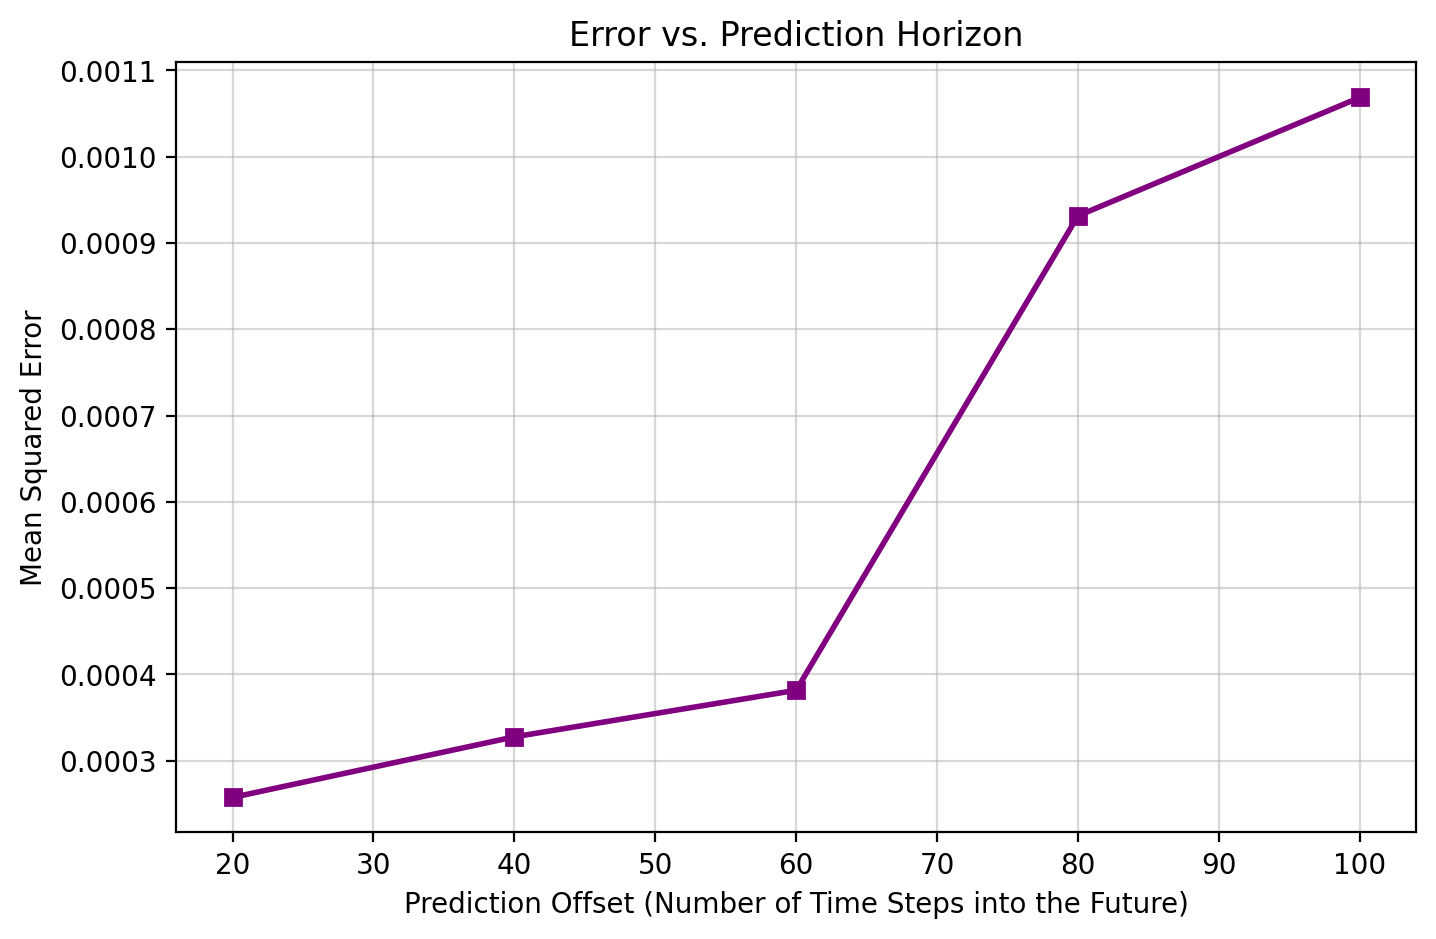

In [12]:
#plotting the increase of error with prediction
plt.figure(figsize=(8, 5))
plt.plot(offsets_to_test, extrapolation_errors, marker='s', color='purple', linestyle='-', linewidth=2)
plt.title("Error vs. Prediction Horizon")
plt.xlabel("Prediction Offset (Number of Time Steps into the Future)")
plt.ylabel("Mean Squared Error")
plt.grid(True, alpha=0.5)
plt.show()

The trend reveals rapid increase in error as the prediction offset increases. This is because as you increase the offset, there is a large gap for the model to fill in before its given data and the data it is predicting. 

## Repeated tests but for much more chaotic initial conditions of: $z_0=[\pi/2,0,\pi/2,0]$

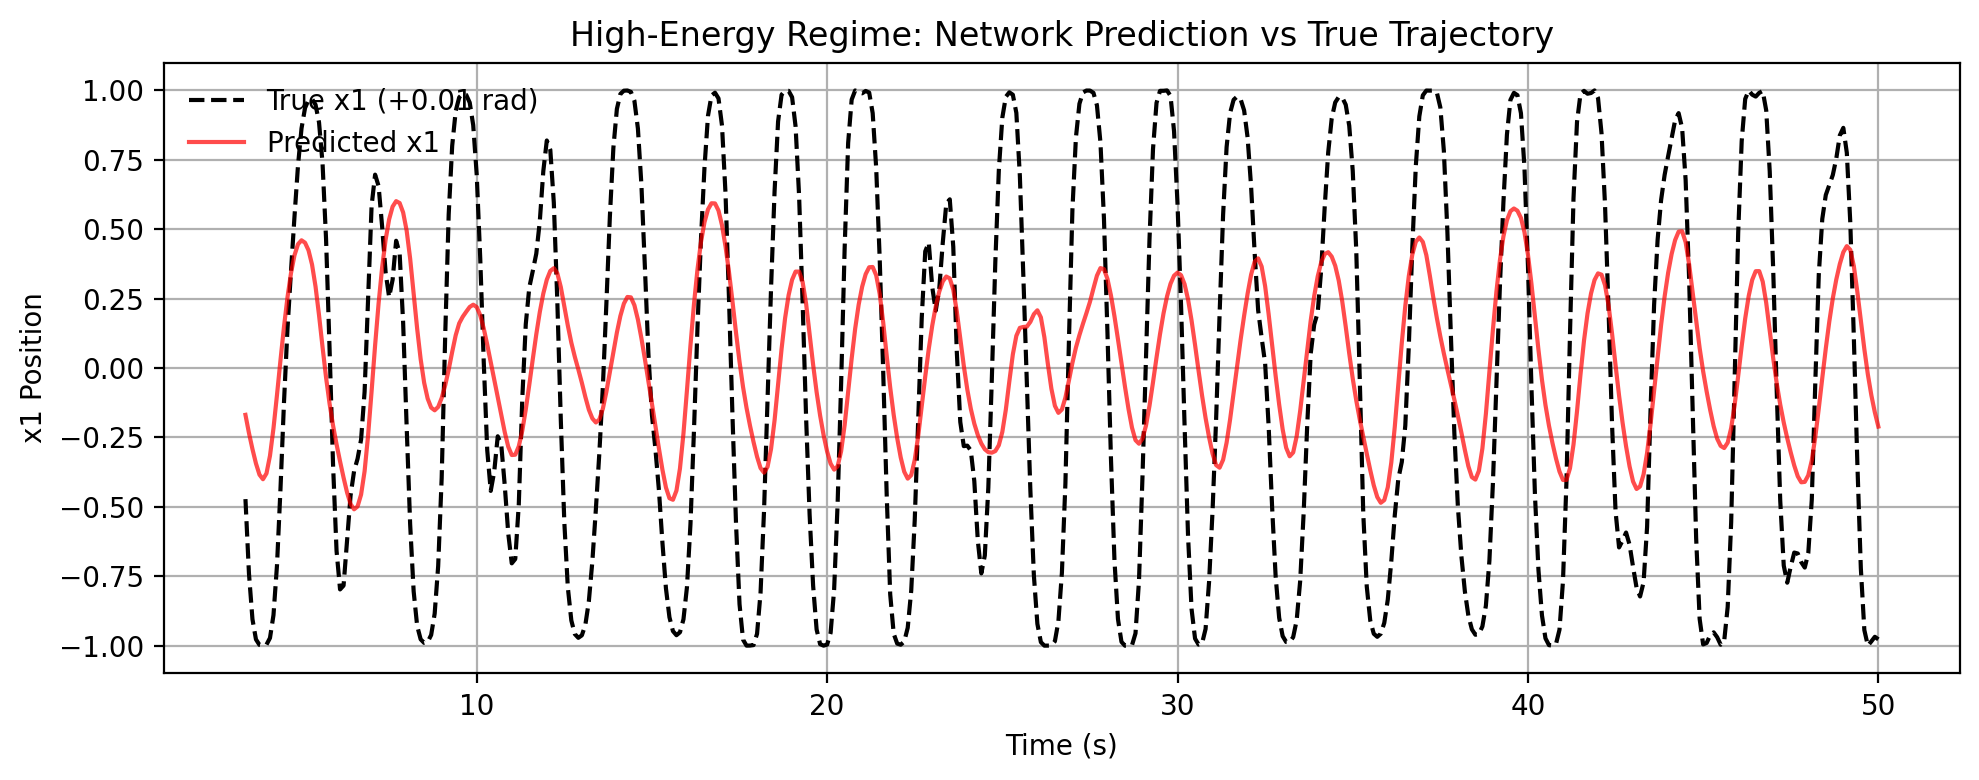

In [13]:
# generate new data
# high energy
data_high_train, _ = env.generate_data([np.pi/2, 0, np.pi/2, 0], 2000)
# high energy with variance
data_high_test, t_test = env.generate_data([np.pi/2 + 0.01, 0, np.pi/2, 0], 50)

# scale the data (fit ONLY on training data to prevent leakage)
scaler_high = StandardScaler()
data_high_train_scaled = scaler_high.fit_transform(data_high_train)
data_high_test_scaled = scaler_high.transform(data_high_test)

# format the data to inputs using the vectorized function
xTrain_in, xTrain_label_scaled = create_windows_vectorized(data_high_train_scaled, windowsize, offset)
xTest_in, xTest_label_scaled = create_windows_vectorized(data_high_test_scaled, windowsize, offset)

# initialise model
model_high = build_lstm_model(input_dim=4, output_dim=4)

# initialize early stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# train model using standard Keras protocols
model_high.fit(
    xTrain_in, xTrain_label_scaled,
    epochs=50,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[early_stop],
    shuffle=True,
    verbose=0
)

# evaluate
predictions_high_scaled = model_high.predict(xTest_in, verbose=0)

# transform predictions and labels back to original physical scale
predictions_high = scaler_high.inverse_transform(predictions_high_scaled)
xTest_label = scaler_high.inverse_transform(xTest_label_scaled)

t_plot = t_test[windowsize + offset - 1 : ]

# plot prediction vs trajectory
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(t_plot, xTest_label[:, 0], label="True x1 (+0.01 rad)", color='black', linestyle='dashed')
ax1.plot(t_plot, predictions_high[:, 0], label="Predicted x1", color='red', alpha=0.7)
ax1.set_ylabel("x1 Position")
ax1.set_xlabel("Time (s)")
ax1.set_title("High-Energy Regime: Network Prediction vs True Trajectory")
ax1.legend()
ax1.grid()
plt.tight_layout()
plt.show()

High-Energy MSE for offset 20: 0.3868
High-Energy MSE for offset 40: 0.4585
High-Energy MSE for offset 60: 0.4971
High-Energy MSE for offset 80: 0.5478
High-Energy MSE for offset 100: 0.5735


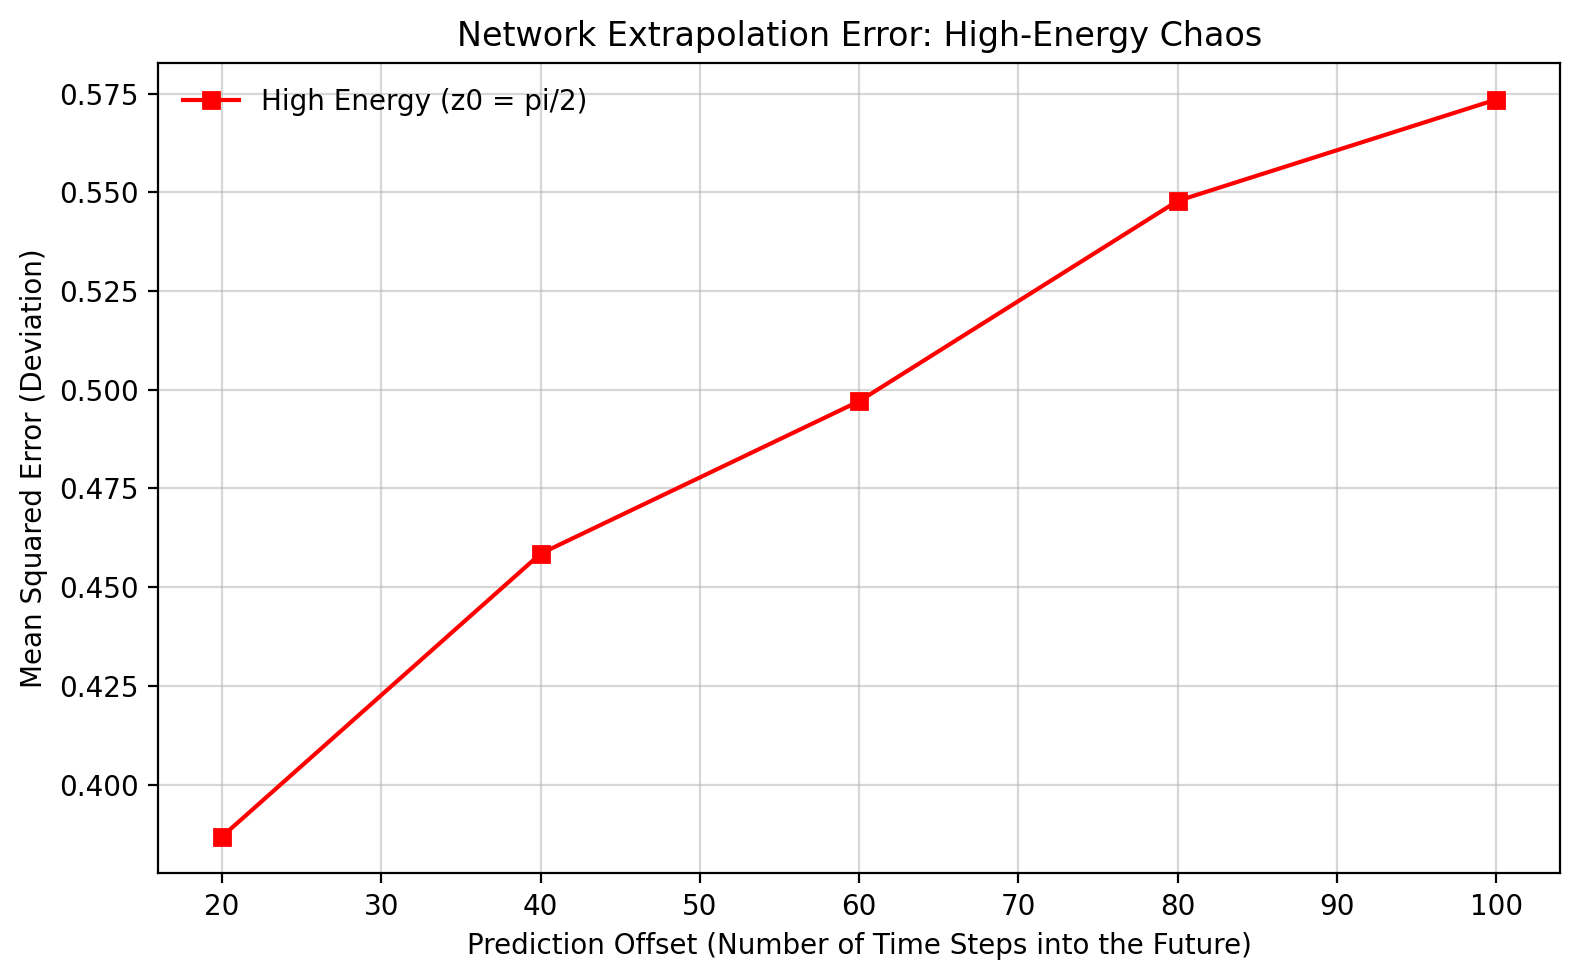

In [14]:
offsets_to_test = [20, 40, 60, 80, 100]
errors_high = []

# loop over offsets
for current_offset in offsets_to_test:
    
    xTrain_in, xTrain_label_scaled = create_windows_vectorized(data_high_train_scaled, windowsize, current_offset)
    xTest_in, xTest_label_scaled = create_windows_vectorized(data_high_test_scaled, windowsize, current_offset)
    
    # model instantiated for this specific offset
    model_offset = build_lstm_model(input_dim=4, output_dim=4)
    
    # train
    model_offset.fit(
        xTrain_in, xTrain_label_scaled,
        epochs=50,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        shuffle=True,
        verbose=0
    )
        
    # evaluate
    predictions_scaled = model_offset.predict(xTest_in, verbose=0)
    
    # transform predictions and labels back to original physical scale
    predictions = scaler_high.inverse_transform(predictions_scaled)
    xTest_label_current = scaler_high.inverse_transform(xTest_label_scaled)
    
    # calculate MSE
    mse = mean_squared_error(xTest_label_current, predictions)
    errors_high.append(mse)
    print(f"High-Energy MSE for offset {current_offset}: {mse:.4f}")

# plotting the comparison
plt.figure(figsize=(8, 5))
plt.plot(offsets_to_test, errors_high, marker='s', color='red', label="High Energy (z0 = pi/2)")
plt.title("Network Extrapolation Error: High-Energy Chaos")
plt.xlabel("Prediction Offset (Number of Time Steps into the Future)")
plt.ylabel("Mean Squared Error (Deviation)")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

This initially starts at a much higher error than the pi/4 state as it is in a higher energy state, the pendulum is a lot more chaotic to start with and is harder to predict from the beginning. This also leads to an even greater increase in error as the offset increases. This shows how unstable and diffficult to predict the system is

## Repeating all steps, however only using data of Mass 2 to make predicitions

In [15]:
# define a single function that handles formatting, training, and testing
def evaluate_blind_regime(train_data, test_data, offsets, epochs=50, batch_size=128):
    # blind the network (isolate mass2)
    train_m2 = train_data[:, 2:4]
    test_m2 = test_data[:, 2:4]
    
    # scale the isolated data to prevent data leakage and ensure convergence
    scaler_blind = StandardScaler()
    train_m2_scaled = scaler_blind.fit_transform(train_m2)
    test_m2_scaled = scaler_blind.transform(test_m2)
    
    errors = []
    plot_data = {}
    
    # initialize early stopping
    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True
    )
    
    for current_offset in offsets:
        print(f"Training Blind Model | Offset: {current_offset}...")
        
        # formatting data to windows using the vectorized function
        xTrain, yTrain_scaled = create_windows_vectorized(train_m2_scaled, windowsize, current_offset)
        xTest, yTest_scaled = create_windows_vectorized(test_m2_scaled, windowsize, current_offset)
        
        # build the model (input_dim=2, output_dim=2 for Mass 2 only)
        model = build_lstm_model(input_dim=2, output_dim=2)
        
        # train the model using standard Keras protocols
        model.fit(
            xTrain, yTrain_scaled,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stop],
            shuffle=True,
            verbose=0
        )

        # evaluate on scaled data
        predictions_scaled = model.predict(xTest, verbose=0)
        
        # transform predictions and labels back to original physical scale
        predictions = scaler_blind.inverse_transform(predictions_scaled)
        yTest = scaler_blind.inverse_transform(yTest_scaled)
        
        # calculate mse on physical coordinates
        mse = mean_squared_error(yTest, predictions)
        errors.append(mse)

        # plot data for graph from part 2
        if current_offset == 20:
            plot_data['preds'] = predictions
            plot_data['truth'] = yTest
            
    return errors, plot_data

# generate blind regime errors and plot data
blind_errors_low, blind_plot_data_low = evaluate_blind_regime(pendulum_data, test_data, offsets_to_test)
blind_errors_high, blind_plot_data_high = evaluate_blind_regime(data_high_train, data_high_test, offsets_to_test)

Training Blind Model | Offset: 20...
Training Blind Model | Offset: 40...
Training Blind Model | Offset: 60...
Training Blind Model | Offset: 80...
Training Blind Model | Offset: 100...
Training Blind Model | Offset: 20...
Training Blind Model | Offset: 40...
Training Blind Model | Offset: 60...
Training Blind Model | Offset: 80...
Training Blind Model | Offset: 100...


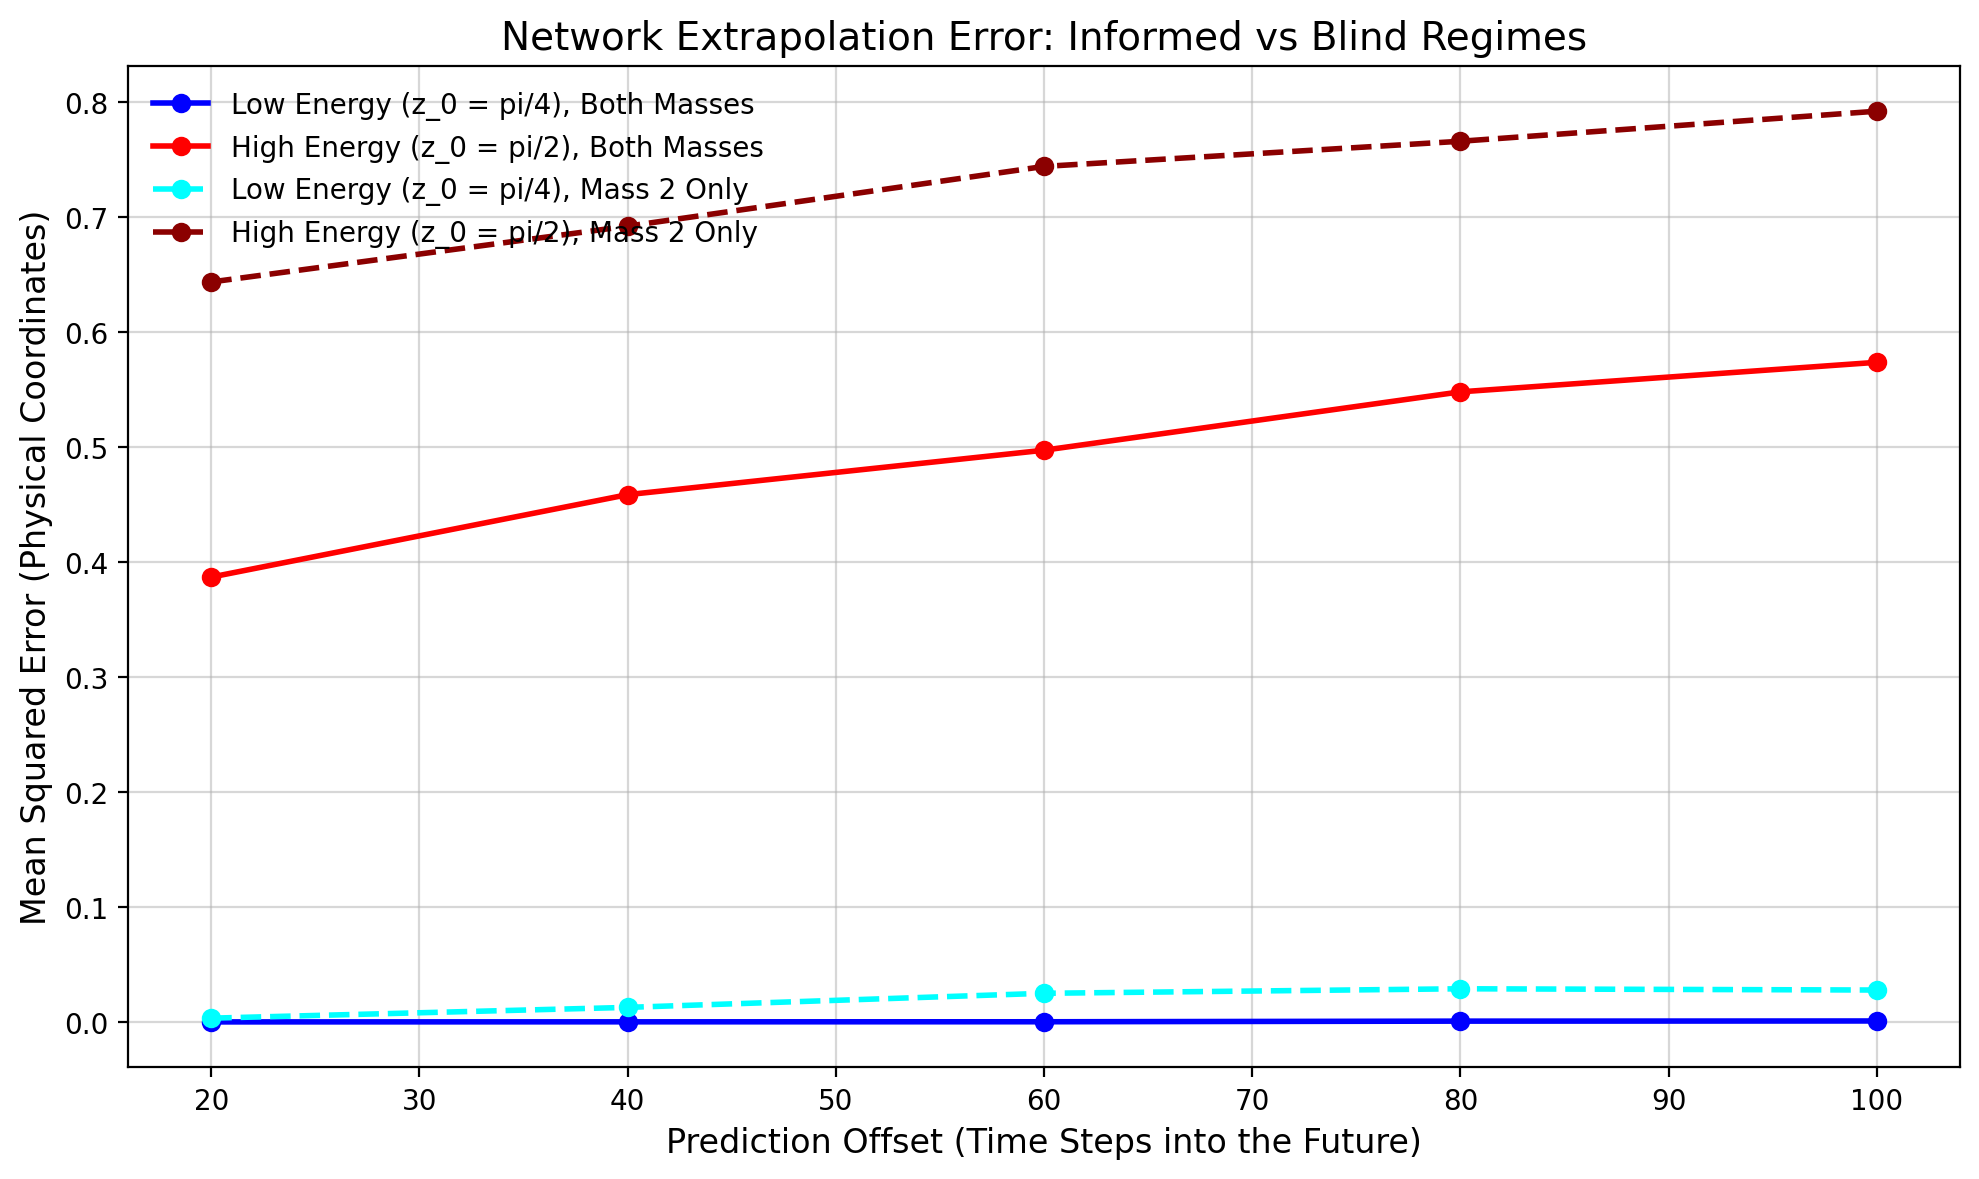

In [16]:
plt.figure(figsize=(10, 6))

# plot the informed models (from previous cells)
plt.plot(offsets_to_test, extrapolation_errors, marker='o', color='blue', linestyle='-',
         linewidth=2, label="Low Energy (z_0 = pi/4), Both Masses")
plt.plot(offsets_to_test, errors_high, marker='o', color='red', linestyle='-',
         linewidth=2, label="High Energy (z_0 = pi/2), Both Masses")

# plot the blinded models
plt.plot(offsets_to_test, blind_errors_low, marker='o', color='cyan', linestyle='--',
         linewidth=2, label="Low Energy (z_0 = pi/4), Mass 2 Only")
plt.plot(offsets_to_test, blind_errors_high, marker='o', color='darkred', linestyle='--',
         linewidth=2, label="High Energy (z_0 = pi/2), Mass 2 Only")

plt.title("Network Extrapolation Error: Informed vs Blind Regimes", fontsize=14)
plt.xlabel("Prediction Offset (Time Steps into the Future)", fontsize=12)
plt.ylabel("Mean Squared Error (Physical Coordinates)", fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

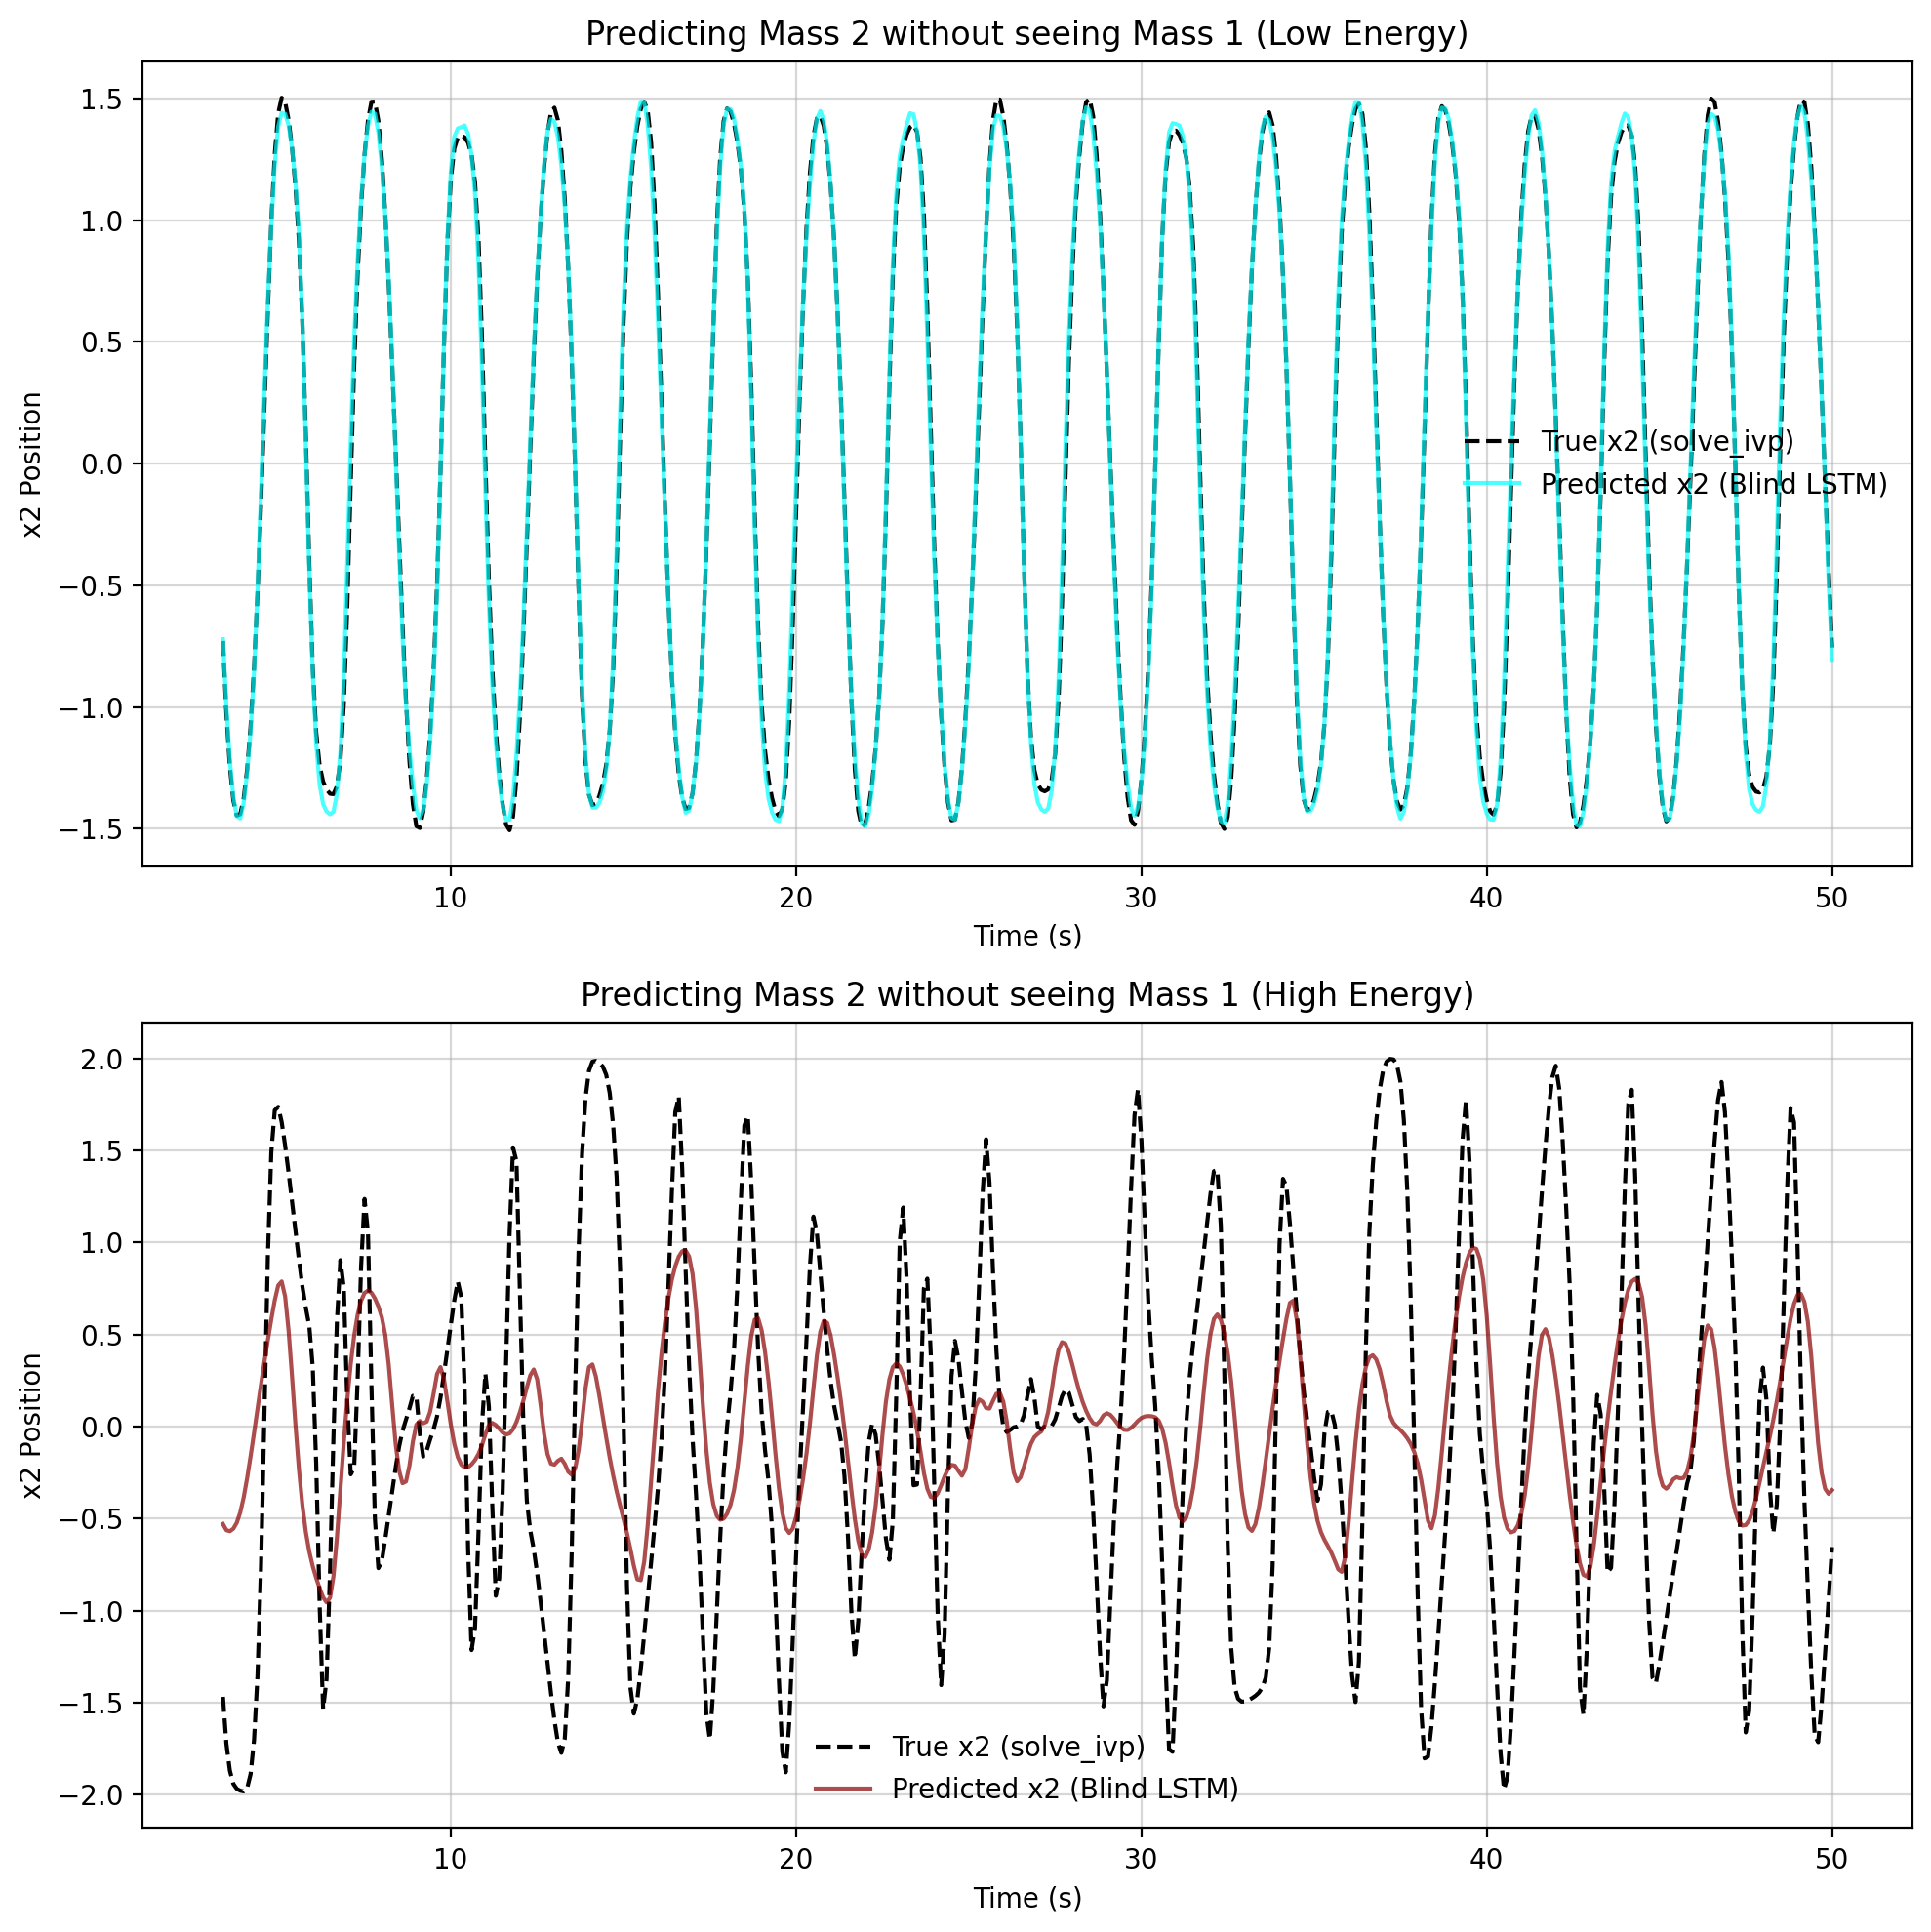

In [17]:
# plot the model prediction for offset=20
t_plot = t_test[windowsize + 20 - 1 : ]
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

ax1 = axes[0]
ax1.plot(t_plot, blind_plot_data_low['truth'][:, 0], label="True x2 (solve_ivp)", color='black', linestyle='dashed')
ax1.plot(t_plot, blind_plot_data_low['preds'][:, 0], label="Predicted x2 (Blind LSTM)", color='cyan', alpha=0.7)
ax1.set_ylabel("x2 Position")
ax1.set_xlabel("Time (s)")
ax1.set_title("Predicting Mass 2 without seeing Mass 1 (Low Energy)")
ax1.legend()
ax1.grid(True, alpha=0.5)

ax2 = axes[1]
ax2.plot(t_plot, blind_plot_data_high['truth'][:, 0], label="True x2 (solve_ivp)", color='black', linestyle='dashed')
ax2.plot(t_plot, blind_plot_data_high['preds'][:, 0], label="Predicted x2 (Blind LSTM)", color='darkred', alpha=0.7)
ax2.set_ylabel("x2 Position")
ax2.set_xlabel("Time (s)")
ax2.set_title("Predicting Mass 2 without seeing Mass 1 (High Energy)")
ax2.legend()
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

when we restrict the input data to only mass 2 the network loses the explicit information it had before about mass 1, which governed the movement of mass 1. As a consequence the error of this system is much higher than the model from before, however, it doesn't fail completely, and performs similarly on the low energy data. This is because the sequence of mass 2 still has the velocity and acceleration in its data, its just not explicitly statesd now. Therefore, the LSTM can make a prediction and infer the position of mass 2 and infer the hidden constraints of mass 1.

We can also see that, similar to the model that can see both data, the mass 2 only model's error increases as the value of offset increases. We can also see that a high energy system gives a much larger increase in error than a low energy system only using Mass 2 data.